In [72]:
import pandas as pd
import numpy as np

df = pd.read_csv("student_depression_dataset.csv")

df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [73]:
missing_values = df.isnull().sum()
print(missing_values)

missing_percent = (missing_values / len(df)) *100
print(missing_percent)

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64
id                                       0.0
Gender                                   0.0
Age                                      0.0
City                                     0.0
Profession                       

In [74]:
num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

df = df.drop_duplicates()

Number of duplicate rows: 0


In [75]:
expected_ranges = {
    'Academic Pressure': (0, 5),    
    'Work Pressure': (0, 5),    
    'CGPA': (0,10),
    'Study Satisfaction': (0, 5),
    'Job Satisfaction': (0, 5),
    'Work/Study Hours': (0, 12),
    'Depression': (0, 1),
}


In [76]:
for col, (min_val, max_val) in expected_ranges.items():
    if col in df.columns:
        invalid = df[(df[col] < min_val) | (df[col] > max_val)]
        if invalid.empty:
            print(f"{col}: no invalid values found.")
        else:
            print(f"{col}: invalid values detected.")


Academic Pressure: no invalid values found.
Work Pressure: no invalid values found.
CGPA: no invalid values found.
Study Satisfaction: no invalid values found.
Job Satisfaction: no invalid values found.
Work/Study Hours: no invalid values found.
Depression: no invalid values found.


In [77]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())



Gender unique values:
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City unique values:
City
Kalyan                  1570
Srinagar                1372
Hyderabad               1340
Vasai-Virar             1290
Lucknow                 1155
Thane                   1139
Ludhiana                1111
Agra                    1094
Surat                   1078
Kolkata                 1066
Jaipur                  1036
Patna                   1007
Visakhapatnam            969
Pune                     968
Ahmedabad                951
Bhopal                   934
Chennai                  885
Meerut                   825
Rajkot                   816
Delhi                    768
Bangalore                767
Ghaziabad                745
Mumbai                   699
Vadodara                 694
Varanasi                 685
Nagpur                   651
Indore                   643
Kanpur                   609
Nashik                   547
Faridabad                461
Saanvi          

In [78]:
invalid_city_values = [
    'Saanvi', 'Bhavna', 'Harsha', 'Gaurav', 'M.Tech', 'M.Com',
    'ME', '3.0', 'City', "'Less Delhi'", "'Less than 5 Kalyan'",
    'Mira', 'Vaanya', 'Reyansh', 'Kibara', 'Rashi', 'Mihir',
    'Nalini', 'Nandini'
]

df['City'] = df['City'].replace(invalid_city_values, 'Others')

df['City'] = df['City'].replace({
    'Khaziabad': 'Ghaziabad',
    'Nalyan': 'Kalyan'
})

In [79]:
"""
df['Profession'] = df['Profession'].apply(
    lambda x: x if x == 'Student' else 'Other'
)
"""


"\ndf['Profession'] = df['Profession'].apply(\n    lambda x: x if x == 'Student' else 'Other'\n)\n"

In [80]:
df['Sleep Duration'] = df['Sleep Duration'].astype(str).str.replace("'", "")
df['Dietary Habits'] = df['Dietary Habits'].astype(str).str.replace("'", "")
df['Sleep Duration'] = df['Sleep Duration'].replace('Others', 'Unknown')
df['Dietary Habits'] = df['Dietary Habits'].replace('Others', 'Unknown')

df['Financial Stress'] = df['Financial Stress'].replace('?', np.nan)
df['Financial Stress'] = df['Financial Stress'].astype(float)
df['Financial Stress'] = df['Financial Stress'].fillna(
    df['Financial Stress'].median()
)
df['Financial Stress'].dtype



dtype('float64')

In [81]:
df.describe()


,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139852,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437270,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


In [82]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]
    print(f"{col}: {len(outliers)} potential outliers")


id: 0 potential outliers
Age: 12 potential outliers
Academic Pressure: 0 potential outliers
Work Pressure: 3 potential outliers
CGPA: 9 potential outliers
Study Satisfaction: 0 potential outliers
Job Satisfaction: 8 potential outliers
Work/Study Hours: 0 potential outliers
Financial Stress: 0 potential outliers
Depression: 0 potential outliers


In [83]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts())



Gender unique values:
Gender
Male      15547
Female    12354
Name: count, dtype: int64

City unique values:
City
Kalyan           1571
Srinagar         1372
Hyderabad        1340
Vasai-Virar      1290
Lucknow          1155
Thane            1139
Ludhiana         1111
Agra             1094
Surat            1078
Kolkata          1066
Jaipur           1036
Patna            1007
Visakhapatnam     969
Pune              968
Ahmedabad         951
Bhopal            934
Chennai           885
Meerut            825
Rajkot            816
Delhi             768
Bangalore         767
Ghaziabad         746
Mumbai            699
Vadodara          694
Varanasi          685
Nagpur            651
Indore            643
Kanpur            609
Nashik            547
Faridabad         461
Others             23
Harsh               1
Name: count, dtype: int64

Profession unique values:
Profession
Student                     27870
Architect                       8
Teacher                         6
'Digital Markete

In [84]:
if 'id' in df.columns:
    df = df.drop(columns=['id'])

In [85]:
import numpy as np
import json
from sklearn.preprocessing import LabelEncoder

category_mappings = {}
binary_map = {'Yes': 1, 'No': 0}

binary_cols = [
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]

for col in binary_cols:
    df[col] = df[col].map(binary_map)
    category_mappings[col] = binary_map


df['Sleep Duration'] = df['Sleep Duration'].replace('Unknown', np.nan)
df['Dietary Habits'] = df['Dietary Habits'].replace('Unknown', np.nan)

sleep_map = {
    'Less than 5 hours': 0,
    '5-6 hours': 1,
    '7-8 hours': 2,
    'More than 8 hours': 3
}

diet_map = {
    'Unhealthy': 0,
    'Moderate': 1,
    'Healthy': 2
}

df['Sleep Duration'] = df['Sleep Duration'].map(sleep_map)
df['Dietary Habits'] = df['Dietary Habits'].map(diet_map)

category_mappings['Sleep Duration'] = sleep_map
category_mappings['Dietary Habits'] = diet_map


df = df.dropna()

le = LabelEncoder()
categorical_cols = ['Gender', 'City', 'Profession', 'Degree']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    mapping_dict = dict(zip(le.classes_.astype(str), range(len(le.classes_))))
    category_mappings[col] = mapping_dict


In [86]:
with open('category_mappings_v2.json', 'w') as f:
    json.dump(category_mappings, f, indent=4)

df.to_csv('processed_data_v2.csv', index=False)

print("Data cleaned, encoded, and saved.")
print("\nFinal Data Types:")
print(df.dtypes)

Data cleaned, encoded, and saved.

Final Data Types:
Gender                                     int64
Age                                      float64
City                                       int64
Profession                                 int64
Academic Pressure                        float64
Work Pressure                            float64
CGPA                                     float64
Study Satisfaction                       float64
Job Satisfaction                         float64
Sleep Duration                           float64
Dietary Habits                           float64
Degree                                     int64
Have you ever had suicidal thoughts ?      int64
Work/Study Hours                         float64
Financial Stress                         float64
Family History of Mental Illness           int64
Depression                                 int64
dtype: object


In [87]:
print(df.shape)
df.head()


(27871, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,1,33.0,31,12,5.0,0.0,8.97,2.0,0.0,1.0,2.0,4,1,3.0,1.0,0,1
1,0,24.0,2,12,2.0,0.0,5.90,5.0,0.0,1.0,1.0,11,0,3.0,2.0,1,0
2,1,31.0,25,12,3.0,0.0,7.03,5.0,0.0,0.0,2.0,6,0,9.0,1.0,1,0
3,0,28.0,29,12,3.0,0.0,5.59,2.0,0.0,2.0,1.0,8,1,4.0,5.0,1,1
4,0,25.0,11,12,4.0,0.0,8.13,3.0,0.0,1.0,1.0,17,1,1.0,1.0,0,0


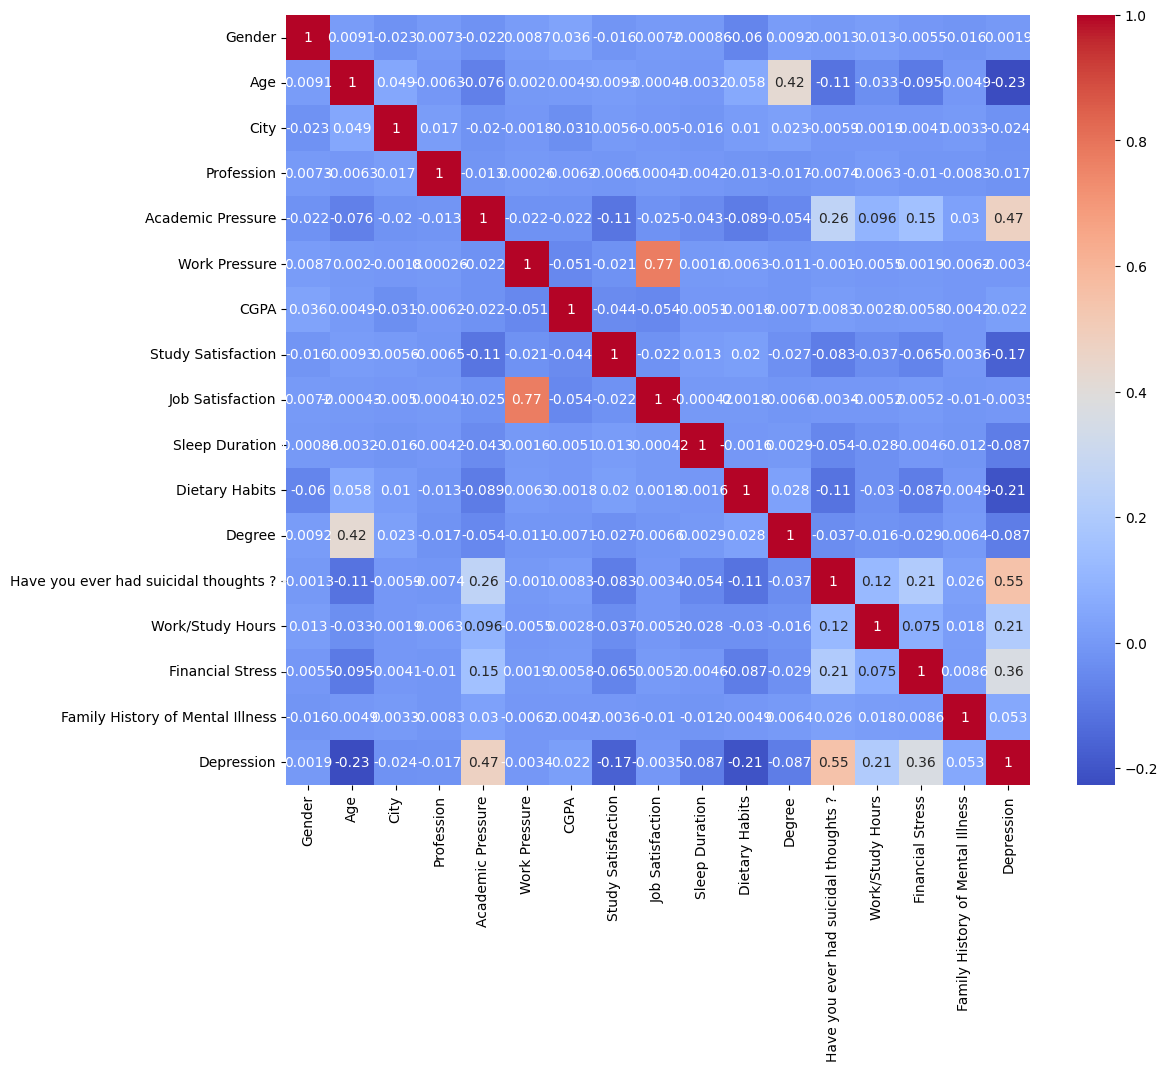

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("processed_data_v2.csv")
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()